### ⚙️ Setup e Carregamento dos dados

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Estilo visual padrão do projeto
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

CAMINHO_RAW = '../data/db/00_bronze_raw/DB_PEDE_RAW.xlsx'

In [43]:
# Carrega todas as abas de uma vez em um dicionário {nome_aba: DataFrame}
df_raw = pd.read_excel(CAMINHO_RAW, sheet_name=None)

print(f'Abas encontradas: {list(df_raw.keys())}\n')

for nome, df in df_raw.items():
    print(f'  {nome}: {df.shape[0]} alunos  |  {df.shape[1]} colunas')

Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']

  PEDE2022: 860 alunos  |  42 colunas
  PEDE2023: 1014 alunos  |  48 colunas
  PEDE2024: 1156 alunos  |  50 colunas


##### 💡 Insights

- O dataset cresce ano a ano: **860 -> 1.014 -> 1.156 alunos** — o programa está em expansão.
- As colunas também aumentam: **42 -> 48 -> 50** — novas métricas/colunas adicionadas ao longo dos anos.
- ⚠️ **Alerta:** Novas colunas significa que uma consolidação direta (vertical) vai gerar **valores nulos** onde as colunas não existiam nos anos anteriores. 

In [44]:
df_raw['PEDE2022'].head()

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


In [45]:
df_raw['PEDE2022'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    object 
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    object 
 3   Nome                   860 non-null    object 
 4   Ano nasc               860 non-null    int64  
 5   Idade 22               860 non-null    int64  
 6   Gênero                 860 non-null    object 
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    object 
 9   Pedra 20               323 non-null    object 
 10  Pedra 21               462 non-null    object 
 11  Pedra 22               860 non-null    object 
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 14  Cf                     860 non-null    int64  
 15  Ct    

In [46]:
# Comparar os nomes de colunas entre as abas para entender o que mudou
cols_2022 = set(df_raw['PEDE2022'].columns)
cols_2023 = set(df_raw['PEDE2023'].columns)
cols_2024 = set(df_raw['PEDE2024'].columns)

print('=== Colunas presentes em 2023 mas ausentes em 2022 ===')
print(sorted(cols_2023 - cols_2022))

print('\n=== Colunas presentes em 2024 mas ausentes em 2023 ===')
print(sorted(cols_2024 - cols_2023))

print('\n=== Colunas presentes em 2022 mas ausentes em 2023 ===')
print(sorted(cols_2022 - cols_2023))

=== Colunas presentes em 2023 mas ausentes em 2022 ===
['Data de Nasc', 'Defasagem', 'Destaque IPV.1', 'Fase Ideal', 'INDE 2023', 'INDE 23', 'IPP', 'Idade', 'Ing', 'Mat', 'Nome Anonimizado', 'Pedra 2023', 'Pedra 23', 'Por']

=== Colunas presentes em 2024 mas ausentes em 2023 ===
['Ativo/ Inativo', 'Ativo/ Inativo.1', 'Avaliador5', 'Avaliador6', 'Escola', 'INDE 2024', 'Pedra 2024']

=== Colunas presentes em 2022 mas ausentes em 2023 ===
['Ano nasc', 'Defas', 'Fase ideal', 'Idade 22', 'Inglês', 'Matem', 'Nome', 'Portug']


##### 💡 Insights

- A chave `RA` (Registro do Aluno) é o identificador único que nos permite rastrear o mesmo aluno ao longo dos anos.

- Coluna `IPP` surgiu em 2023 — **não existe em 2022**. Isso pode ser um limitador
- 2024 ganhou nvoas colunas: `Escola` e `Ativo/Inativo`
- Alguns campos de 2022, como `Nome`, `Ano nasc`, `Idade 22`, foram renomeados ou reestruturados em 2023/2024.


### 🔎 Exploração e qualidade dos dados

In [47]:
# Identificar colunas 100% nulas em cada aba — 'colunas fantasma'
print('=== Colunas 100% nulas por ano (foram descontinuadas ou nunca preenchidas) ===\n')
for nome, df_ano in df_raw.items():
    vazios = [c for c in df_ano.columns if df_ano[c].isnull().all()]
    print(f'  {nome} ({len(vazios)} colunas vazias):')
    for c in vazios:
        print(f'    - {c}')
    print()

=== Colunas 100% nulas por ano (foram descontinuadas ou nunca preenchidas) ===

  PEDE2022 (0 colunas vazias):

  PEDE2023 (16 colunas vazias):
    - Pedra 23
    - INDE 23
    - Cg
    - Cf
    - Ct
    - Rec Av1
    - Rec Av2
    - Rec Av3
    - Rec Av4
    - Rec Psicologia
    - Indicado
    - Atingiu PV
    - Destaque IEG
    - Destaque IDA
    - Destaque IPV
    - Destaque IPV.1

  PEDE2024 (11 colunas vazias):
    - Cg
    - Cf
    - Ct
    - Rec Av1
    - Rec Av2
    - Rec Psicologia
    - Indicado
    - Atingiu PV
    - Destaque IEG
    - Destaque IDA
    - Destaque IPV



##### 💡 Insights

- Colunas `Pedra 23`, `INDE 23`, `Cg`, `Cf`, `Ct`, `Rec Av1–4`, `Rec Psicologia`, `Indicado`, `Atingiu PV` e os `Destaque` estão **100% vazios em 2023 e 2024**.
  - Isso me faz crer que rankings (`Cg/Cf/Ct`) e recomendações (`Rec Av`, `Rec Psicologia`) foram **descontinuados** — não podemos usá-los como features.
- `Ponto de Virada` (`Atingiu PV`) que aparece no dicionário como booleano-chave **não existe em 2023/2024** — importante limitação para o pilar 7 (IPV).


> Essas colunas possivelmente serão descartadas na consolidação, pois não há nada a recuperar delas.

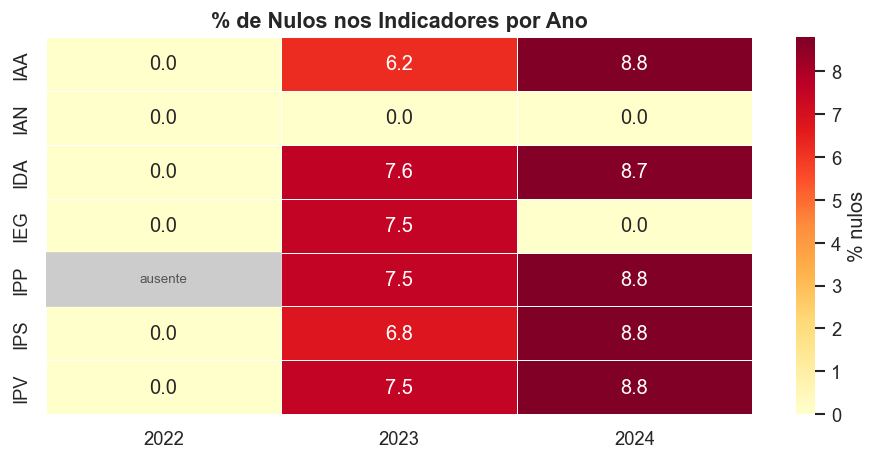

In [48]:
# Mapa de nulos nos indicadores principais por ano
indicadores = ['IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN']

tabela_nulos = []
for nome, df_ano in df_raw.items():
    ano = nome[-4:]
    total = len(df_ano)
    for ind in indicadores:
        if ind in df_ano.columns:
            n = df_ano[ind].isnull().sum()
            tabela_nulos.append({'Ano': ano, 'Indicador': ind, 'Nulos': n, 'Pct': round(n / total * 100, 1)})
        else:
            tabela_nulos.append({'Ano': ano, 'Indicador': ind, 'Nulos': None, 'Pct': None})

df_nulos = pd.DataFrame(tabela_nulos)

# Heatmap de % de nulos
pivot = df_nulos.pivot(index='Indicador', columns='Ano', values='Pct')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': '% nulos'},
    mask=pivot.isna()
)

# Células com None (ausente) em cinza
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        if pd.isna(pivot.iloc[i, j]):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='#cccccc', zorder=3))
            ax.text(j + 0.5, i + 0.5, 'ausente', ha='center', va='center', fontsize=8, color='#555555', zorder=4)

ax.set_title('% de Nulos nos Indicadores por Ano', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

##### 💡 Insights

- **2022 é o mais limpo**: todos os indicadores presentes e sem nulos (exceto `IPP`, que nem existia).
- **2023 e 2024 têm ~7–9% de nulos** nos indicadores avaliados
- `IAN` e `IEG` (em 2024) são os únicos indicadores **sempre preenchidos** (possíveis candidatos para features).

### 🪏 Investigar IPP na base antiga

- Ao revisar manualmente a base antiga "PEDE_PASSOS_DATASET_FIAP.xlsx", pude encontrar a coluna IPP_2022 nela. 
- Infelizmente, essa base antiga não possui a coluna RA e os nomes dos alunos não batem com os nomes da base atual "DB_PEDE_RAW.xlsx"
- Portanto, será criada um algoritmo para poder identificar os matches através de outras colunas, afim de ajudar na suplementação da coluna IPP para o datagrame de 2022

In [49]:
CAMINHO_AUX   = '../data/db/00_bronze_raw/PEDE_PASSOS_DATASET_FIAP.xlsx'

def decodificar_numero(val: str) -> float:
    """
    Converte strings numéricas da base auxiliar para float.
    O Excel corrompeu frações como datas em dois padrões:
      - ano > 2100: valor = ano / 1000      (ex: '9375-05-01' → 9.375)
      - ano = 2025: Excel leu a fração como data MM/DD
                    valor = float(f'{mes}.{dia}')  (ex: '2025-06-25' → 6.25)
    """
    if pd.isna(val) or val == '': return np.nan
    try: return float(val)
    except ValueError: pass
    try: ano = int(val[:4])
    except ValueError: return np.nan
    if ano > 2100: return ano / 1000
    if ano == 2025:
        mes = int(val[5:7])
        dia = int(val[8:10])
        return float(f'{mes}.{dia}')
    return np.nan

# Ler com dtype=str — evita inferência de tipo pelo pandas
df_aux = pd.read_excel(CAMINHO_AUX, dtype=str)
df_aux = df_aux[df_aux['INDE_2022'].notna()].copy().reset_index(drop=True)

colunas_num_aux = ['FASE_2022','IAN_2022','INDE_2022','IPV_2022',
                   'IAA_2022','IEG_2022','IPS_2022','IDA_2022','IPP_2022']
for col in colunas_num_aux:
    df_aux[col] = df_aux[col].apply(decodificar_numero)

print(f'Base auxiliar: {len(df_aux)} registros')
print(f'IPP_2022 válidos: {df_aux["IPP_2022"].notna().sum()}/{len(df_aux)}')
print(f'IAN únicos: {sorted(df_aux["IAN_2022"].dropna().unique())}')

Base auxiliar: 862 registros
IPP_2022 válidos: 862/862
IAN únicos: [np.float64(2.5), np.float64(5.0), np.float64(10.0)]


In [50]:
df_aux[df_aux['NOME'] == 'ALUNO-1304'].head()

,INSTITUICAO_ENSINO_ALUNO_2020,NOME,IDADE_ALUNO_2020,ANOS_PM_2020,FASE_TURMA_2020,PONTO_VIRADA_2020,INDE_2020,INDE_CONCEITO_2020,PEDRA_2020,DESTAQUE_IEG_2020,...,IPP_2022,REC_AVA_1_2022,REC_AVA_2_2022,REC_AVA_3_2022,REC_AVA_4_2022,INDICADO_BOLSA_2022,PONTO_VIRADA_2022,IPV_2022,IAN_2022,NIVEL_IDEAL_2022
833,NaN,ALUNO-1304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.25,Promovido de Fase,Mantido na Fase atual,Promovido de Fase,NaN,Não,Não,7.541665,2.5,Fase 8 (Universitários)


In [51]:
# Cruzamento: chave categórica + distância euclidiana com ratio de separação

df22 = df_raw['PEDE2022'].copy().reset_index(drop=True)
df_a = df_aux.copy()

# Chave categórica: FASE + TURMA + IAN (discreto) + FASE_IDEAL
# IAN só assume 3 valores (2.5, 5.0, 10.0) e FASE_IDEAL é texto idêntico nas duas bases
df22['_cat'] = (df22['Fase'].astype(str) + '_' + df22['Turma'].astype(str) + '_' +
                df22['IAN'].astype(str)  + '_' + df22['Fase ideal'].astype(str))
df_a['_cat'] = (df_a['FASE_2022'].astype(int).astype(str) + '_' + df_a['TURMA_2022'].astype(str) + '_' +
                df_a['IAN_2022'].astype(str) + '_' + df_a['NIVEL_IDEAL_2022'].astype(str))

# Colunas usadas no desempate numérico (maior precisão entre as bases)
COLS_NOVO   = ['INDE 22', 'IPV', 'IAA']
COLS_ANTIGO = ['INDE_2022', 'IPV_2022', 'IAA_2022']
RATIO       = 0.50  # candidato eleito deve ter dist < 50% da distância do segundo

df22['IPP'] = np.nan

for idx, row in df22.iterrows():
    grupo = df_a[df_a['_cat'] == row['_cat']]

    # Sem candidatos — aluno não existe na base auxiliar
    if len(grupo) == 0:
        continue

    # Candidato único — match direto sem ambiguidade
    if len(grupo) == 1:
        df22.at[idx, 'IPP'] = grupo['IPP_2022'].values[0]
        continue

    # Múltiplos candidatos — desempate por distância euclidiana em [INDE, IPV, IAA]
    # NaN em qualquer dimensão contribui 0 (ignora essa dimensão)
    v_novo   = np.array([row[c] for c in COLS_NOVO], dtype=float)
    matriz_a = df_a.loc[grupo.index, COLS_ANTIGO].to_numpy(dtype=float)
    diffs    = np.where(np.isnan(matriz_a - v_novo), 0, matriz_a - v_novo)
    dists    = np.sqrt((diffs ** 2).sum(axis=1))

    ordem  = np.argsort(dists)
    d1, d2 = dists[ordem[0]], dists[ordem[1]]

    # Aceitar somente se o mais próximo estiver a < 50% da distância do segundo
    if d1 / d2 < RATIO:
        df22.at[idx, 'IPP'] = grupo.iloc[ordem[0]]['IPP_2022']

df22.drop(columns=['_cat'], inplace=True)

total_ipp = df22['IPP'].notna().sum()
print(f'IPP recuperado: {total_ipp}/{len(df22)} ({total_ipp/len(df22)*100:.1f}%)')

IPP recuperado: 860/860 (100.0%)


In [52]:
# confirmando que não há nenhum IPP com valor nulo
df22[df22['IPP'].isna() == True].head()

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,IPP


In [53]:
df_raw['PEDE2022'] = df22

# Verificando o resultado final com a coluna de IPP preenchida
df_raw['PEDE2022'].head()

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,IPP
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,7.96875
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,8.12500
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,8.12500
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,5.62500
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,8.28125


In [54]:
df_raw

{'PEDE2022':          RA  Fase Turma       Nome  Ano nasc  Idade 22  Gênero  Ano ingresso  \
 0      RA-1     7     A    Aluno-1      2003        19  Menina          2016   
 1      RA-2     7     A    Aluno-2      2005        17  Menina          2017   
 2      RA-3     7     A    Aluno-3      2005        17  Menina          2016   
 3      RA-4     7     A    Aluno-4      2005        17  Menino          2017   
 4      RA-5     7     A    Aluno-5      2005        17  Menina          2016   
 ..      ...   ...   ...        ...       ...       ...     ...           ...   
 855  RA-856     0     Z  Aluno-856      2015         7  Menino          2022   
 856  RA-857     0     Z  Aluno-857      2013         9  Menina          2022   
 857  RA-858     0     Z  Aluno-858      2015         7  Menino          2022   
 858  RA-859     0     Z  Aluno-859      2015         7  Menina          2022   
 859  RA-860     0     Z  Aluno-860      2015         7  Menino          2022   
 
     Instituiç

### 📦 Bloco 4 — Consolidação das 3 abas em `df_base`

O objetivo é transformar as 3 abas com nomes, tipos e estruturas diferentes em um único DataFrame padronizado.

In [55]:
# Colunas que vão compor o df_base consolidado
COLUNAS_FINAIS = [
    'ano', 'RA', 'nome', 'genero', 'idade', 'ano_ingresso',
    'instituicao', 'fase', 'turma', 'nivel', 'fase_ideal', 'defasagem',
    'pedra', 'INDE',
    'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV',
    'mat', 'por', 'ing',
    'indicado_bolsa', 'atingiu_pv', 'rec_psicologia',
    # Histórico de pedras para análise longitudinal
    'pedra_20', 'pedra_21', 'pedra_22', 'pedra_23',
]


def extrair_nivel(fase_str, ano: int):
    """
    Extrai o nível numérico a partir da coluna Fase.
    - 2022: já é inteiro (0–8)
    - 2023: texto como 'FASE 1', 'ALFA'
    - 2024: turma como '3B', '7E', 'ALFA', '9'
    """
    fase_str = str(fase_str).strip().upper()

    if fase_str in ('ALFA', 'NAN', ''):
        return 'ALFA'

    if ano == 2022:
        try:
            val = int(fase_str)
            return 'ALFA' if val == 0 else val
        except ValueError:
            return np.nan

    if ano == 2023:
        # Formato: 'FASE 1', 'FASE 2', etc.
        if 'FASE' in fase_str:
            partes = fase_str.split()
            if len(partes) >= 2:
                try:
                    return int(partes[-1])
                except ValueError:
                    pass
        # Pode vir como número direto
        try:
            return int(fase_str)
        except ValueError:
            return np.nan

    if ano == 2024:
        # Formato: '3B', '7E', '9', etc. — nível é o primeiro caractere
        try:
            return int(fase_str[0])
        except (ValueError, IndexError):
            return np.nan

    return np.nan


def padronizar_genero(valor):
    """Padroniza gênero para Feminino/Masculino."""
    mapa = {
        'menina': 'Feminino', 'menino': 'Masculino',
        'feminino': 'Feminino', 'masculino': 'Masculino',
    }
    return mapa.get(str(valor).strip().lower(), np.nan)

In [56]:
# -------------------------------------------------------------------
# 2022 — nomes originais são diferentes de 2023/2024
# -------------------------------------------------------------------
df22 = df_raw['PEDE2022'].copy()

df22['ano']             = 2022
df22['nivel']           = df22['Fase'].apply(lambda x: extrair_nivel(x, 2022))
df22['genero']          = df22['Gênero'].apply(padronizar_genero)
df22['pedra']           = df22['Pedra 22']
df22['INDE']            = df22['INDE 22']
df22['fase_ideal']      = df22['Fase ideal']
df22['fase']            = df22['Fase']
df22['turma']           = df22['Turma']
df22['defasagem']       = df22['Defas']
df22['nome']            = df22['Nome']
df22['idade']           = df22['Idade 22']
df22['ano_ingresso']    = df22['Ano ingresso']
df22['instituicao']     = df22['Instituição de ensino']
df22['mat']             = df22['Matem']
df22['por']             = df22['Portug']
df22['ing']             = df22['Inglês']
df22['indicado_bolsa']  = df22['Indicado']
df22['atingiu_pv']      = df22['Atingiu PV']
df22['rec_psicologia']  = df22['Rec Psicologia']
df22['pedra_20']        = df22.get('Pedra 20')
df22['pedra_21']        = df22.get('Pedra 21')
df22['pedra_22']        = df22['Pedra 22']
df22['pedra_23']        = np.nan  # não existia ainda

# IPP já veio do cruzamento com a base auxiliar
print(f'2022: {len(df22)} registros | IPP preenchido: {df22["IPP"].notna().sum()}/{len(df22)}')
df22[COLUNAS_FINAIS].head(5)

2022: 860 registros | IPP preenchido: 860/860


,ano,RA,nome,genero,idade,ano_ingresso,instituicao,fase,turma,nivel,...,mat,por,ing,indicado_bolsa,atingiu_pv,rec_psicologia,pedra_20,pedra_21,pedra_22,pedra_23
0,2022,RA-1,Aluno-1,Feminino,19,2016,Escola Pública,7,A,7,...,2.7,3.5,6.0,Sim,Não,Requer avaliação,Ametista,Ametista,Quartzo,NaN
1,2022,RA-2,Aluno-2,Feminino,17,2017,Rede Decisão,7,A,7,...,6.3,4.5,9.7,Não,Não,Sem limitações,Ametista,Ametista,Ametista,NaN
2,2022,RA-3,Aluno-3,Feminino,17,2016,Rede Decisão,7,A,7,...,5.8,4.0,6.9,Não,Não,Sem limitações,Ametista,Ametista,Ágata,NaN
3,2022,RA-4,Aluno-4,Masculino,17,2017,Rede Decisão,7,A,7,...,2.8,3.5,8.7,Não,Não,Requer avaliação,Ametista,Ametista,Quartzo,NaN
4,2022,RA-5,Aluno-5,Feminino,17,2016,Rede Decisão,7,A,7,...,7.0,2.9,5.7,Não,Não,Requer avaliação,Ametista,Ametista,Ametista,NaN


In [57]:
# -------------------------------------------------------------------
# 2023
# -------------------------------------------------------------------
df23 = df_raw['PEDE2023'].copy()

df23['ano']             = 2023
df23['nivel']           = df23['Fase'].apply(lambda x: extrair_nivel(x, 2023))
df23['genero']          = df23['Gênero'].apply(padronizar_genero)
df23['pedra']           = df23['Pedra 2023']
df23['INDE']            = df23['INDE 2023']
df23['fase_ideal']      = df23['Fase Ideal']
df23['fase']            = df23['Fase']
df23['turma']           = df23['Turma']
df23['defasagem']       = df23['Defasagem']
df23['nome']            = df23['Nome Anonimizado']
df23['idade']           = pd.to_numeric(df23['Idade'], errors='coerce')
df23['ano_ingresso']    = df23['Ano ingresso']
df23['instituicao']     = df23['Instituição de ensino']
df23['mat']             = df23['Mat']
df23['por']             = df23['Por']
df23['ing']             = df23['Ing']
df23['indicado_bolsa']  = df23.get('Indicado')
df23['atingiu_pv']      = df23.get('Atingiu PV')
df23['rec_psicologia']  = df23.get('Rec Psicologia')
df23['pedra_20']        = df23.get('Pedra 20')
df23['pedra_21']        = df23.get('Pedra 21')
df23['pedra_22']        = df23.get('Pedra 22')
df23['pedra_23']        = df23['Pedra 2023']

print(f'2023: {len(df23)} registros | Nível distribuição:')
print(df23['nivel'].astype(str).value_counts().sort_index().to_string())
df23[COLUNAS_FINAIS].head(3)

2023: 1014 registros | Nível distribuição:
nivel
1       173
2       200
3       132
4        94
5        65
6        33
7        23
8        63
ALFA    231


,ano,RA,nome,genero,idade,ano_ingresso,instituicao,fase,turma,nivel,...,mat,por,ing,indicado_bolsa,atingiu_pv,rec_psicologia,pedra_20,pedra_21,pedra_22,pedra_23
0,2023,RA-861,Aluno-861,Feminino,8.0,2023,Pública,ALFA,ALFA A - G0/G1,ALFA,...,9.8,9.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Topázio
1,2023,RA-862,Aluno-862,Masculino,9.0,2023,Pública,ALFA,ALFA A - G0/G1,ALFA,...,8.5,9.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Topázio
2,2023,RA-863,Aluno-863,Masculino,7.0,2023,Pública,ALFA,ALFA A - G0/G1,ALFA,...,7.0,5.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Quartzo


In [58]:
# -------------------------------------------------------------------
# 2024 — Fase contém turma (ex: '3B', '7E'), não nível
# -------------------------------------------------------------------
df24 = df_raw['PEDE2024'].copy()

df24['ano']             = 2024
df24['nivel']           = df24['Fase'].apply(lambda x: extrair_nivel(x, 2024))
df24['genero']          = df24['Gênero'].apply(padronizar_genero)
df24['pedra']           = df24['Pedra 2024'].replace('INCLUIR', np.nan)
df24['INDE']            = pd.to_numeric(df24['INDE 2024'], errors='coerce')
df24['fase_ideal']      = df24['Fase Ideal']
df24['fase']            = df24['Fase']
df24['turma']           = df24['Turma']
df24['defasagem']       = df24['Defasagem']
df24['nome']            = df24['Nome Anonimizado']
df24['idade']           = pd.to_numeric(df24['Idade'], errors='coerce')
df24['ano_ingresso']    = df24['Ano ingresso']
df24['instituicao']     = df24['Instituição de ensino']
df24['mat']             = df24['Mat']
df24['por']             = df24['Por']
df24['ing']             = df24['Ing']
df24['indicado_bolsa']  = df24.get('Indicado')
df24['atingiu_pv']      = df24.get('Atingiu PV')
df24['rec_psicologia']  = df24.get('Rec Psicologia')
df24['pedra_20']        = df24.get('Pedra 20')
df24['pedra_21']        = df24.get('Pedra 21')
df24['pedra_22']        = df24.get('Pedra 22')
df24['pedra_23']        = df24.get('Pedra 23')

print(f'2024: {len(df24)} registros | INDE nulos (eram texto): {df24["INDE"].isna().sum()}')
print(f'Pedra "INCLUIR" convertido para NaN: {df24["pedra"].isna().sum()} nulos')
print(f'\nNível distribuição:')
print(df24['nivel'].astype(str).value_counts().sort_index().to_string())

2024: 1156 registros | INDE nulos (eram texto): 102
Pedra "INCLUIR" convertido para NaN: 102 nulos

Nível distribuição:
nivel
1       185
2       185
3       211
4       115
5       100
6        25
7        37
8        64
9        38
ALFA    196


In [59]:
# -------------------------------------------------------------------
# Concatenar as 3 abas
# -------------------------------------------------------------------
df_base = pd.concat(
    [df22[COLUNAS_FINAIS], df23[COLUNAS_FINAIS], df24[COLUNAS_FINAIS]],
    ignore_index=True
)

# Arrumar nome da pedra (acentuação) para evitar inconsistências futuras
df_base['pedra']    = df_base['pedra'].replace('Agata', 'Ágata')
df_base['pedra_20'] = df_base['pedra_20'].replace('Agata', 'Ágata')
df_base['pedra_21'] = df_base['pedra_21'].replace('Agata', 'Ágata')
df_base['pedra_22'] = df_base['pedra_22'].replace('Agata', 'Ágata')
df_base['pedra_23'] = df_base['pedra_23'].replace('Agata', 'Ágata')

# Garantir tipos corretos
df_base['ano']          = df_base['ano'].astype(int)
df_base['nivel']        = df_base['nivel'].astype(str)
df_base['fase']         = df_base['fase'].astype(str)
df_base['turma']        = df_base['turma'].astype(str)
df_base['defasagem']    = pd.to_numeric(df_base['defasagem'], errors='coerce').astype('Int64')
df_base['ano_ingresso'] = pd.to_numeric(df_base['ano_ingresso'], errors='coerce').astype('Int64')
df_base['idade']        = pd.to_numeric(df_base['idade'], errors='coerce').astype('Int64')

print(f'df_base consolidado: {df_base.shape[0]} linhas  |  {df_base.shape[1]} colunas')
print(f'\nRegistros por ano:')
print(df_base['ano'].value_counts().sort_index().to_string())

df_base consolidado: 3030 linhas  |  31 colunas

Registros por ano:
ano
2022     860
2023    1014
2024    1156


In [60]:
# Verificação de nulos por coluna
nulos = df_base.isnull().sum()
nulos_pct = (nulos / len(df_base) * 100).round(1)

df_nulos_check = pd.DataFrame({
    'nulos': nulos,
    'pct': nulos_pct
}).query('nulos > 0').sort_values('pct', ascending=False)

print('=== Colunas com nulos ===')
print(df_nulos_check.to_string())

# Verificar se nivel está correto
print(f'\n=== Distribuição de nivel por ano ===')
print(pd.crosstab(df_base['ano'], df_base['nivel'], margins=True))

=== Colunas com nulos ===
                nulos   pct
pedra_20         2276  75.1
rec_psicologia   2170  71.6
atingiu_pv       2170  71.6
indicado_bolsa   2170  71.6
pedra_21         1969  65.0
ing              1939  64.0
pedra_23         1409  46.5
pedra_22         1098  36.2
idade             399  13.2
por               185   6.1
INDE              185   6.1
pedra             185   6.1
mat               184   6.1
IPV               178   5.9
IPP               178   5.9
IDA               178   5.9
IPS               171   5.6
IAA               165   5.4
IEG                76   2.5
instituicao         1   0.0

=== Distribuição de nivel por ano ===
nivel    1    2    3    4    5   6   7    8   9  ALFA   All
ano                                                        
2022   192  155  148   76   60  18  21    0   0   190   860
2023   173  200  132   94   65  33  23   63   0   231  1014
2024   185  185  211  115  100  25  37   64  38   196  1156
All    550  540  491  285  225  76  81  127  38

In [61]:
# Salvar o df_base consolidado em parquet para manter os tipos das colunas (Int64, float, etc.)
# e evitar conversões desnecessárias ao reabrir o arquivo no futuro. 

os.makedirs('../data/db/01_silver_processed', exist_ok=True)
df_base.to_parquet('../data/db/01_silver_processed/df_base.parquet', index=False)

print(f'✅ Salvo em ../data/db/01_silver_processed/df_base.parquet')
print(f'   {df_base.shape[0]} linhas  |  {df_base.shape[1]} colunas')

✅ Salvo em ../data/db/01_silver_processed/df_base.parquet
   3030 linhas  |  31 colunas
